<a href="https://colab.research.google.com/github/YazidSupriadi14/Data-Science-Portofolio/blob/main/Corn_Leaf_Diseases_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [CORN Leaf Diseases Classification]
- **Nama:** [Muhammad Yazid Supriadi]
- **Email:** [yazidsupriadi1406@gmail.com]



## Import All Packages/Libraries That Are Used


In [2]:
!pip install -q tensorflowjs
!pip install tensorflow==2.19.0 tensorflow-decision-forests==1.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.7.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
bigquery-magics 0.14.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is 

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import time
from PIL import Image as PILImage
from sklearn.metrics import confusion_matrix, classification_report


import kagglehub

import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import os
import shutil

import tensorflowjs as tfjs
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from PIL import Image
import gradio as gr
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mn_preprocess_input


ModuleNotFoundError: No module named 'tensorflowjs'

# **Data Loading**

In [ ]:
!pip install kagglehub

In [ ]:
kagglehub.login()

In [ ]:
!kaggle datasets download -d yusufmurtaza01/corn-leaf-diseases

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/corn-leaf-diseases
License(s): CC0-1.0
100% 110M/110M [00:01<00:00, 67.5MB/s]



### Load Image Data

In [ ]:
!unzip corn-leaf-diseases.zip

Streaming output truncated to the last 5000 lines.
  inflating: corn/images/train/pv_CNLB_image (800).jpg  
  inflating: corn/images/train/pv_CNLB_image (801).jpg  
  inflating: corn/images/train/pv_CNLB_image (802).jpg  
  inflating: corn/images/train/pv_CNLB_image (803).jpg  
  inflating: corn/images/train/pv_CNLB_image (804).jpg  
  inflating: corn/images/train/pv_CNLB_image (805).jpg  
  inflating: corn/images/train/pv_CNLB_image (808).jpg  
  inflating: corn/images/train/pv_CNLB_image (809).jpg  
  inflating: corn/images/train/pv_CNLB_image (810).jpg  
  inflating: corn/images/train/pv_CNLB_image (811).jpg  
  inflating: corn/images/train/pv_CNLB_image (812).jpg  
  inflating: corn/images/train/pv_CNLB_image (814).jpg  
  inflating: corn/images/train/pv_CNLB_image (815).jpg  
  inflating: corn/images/train/pv_CNLB_image (817).jpg  
  inflating: corn/images/train/pv_CNLB_image (818).jpg  
  inflating: corn/images/train/pv_CNLB_image (819).jpg  
  inflating: corn/images/train/pv_CNL

## Data Preparation

In [ ]:
# determine the path
path = '/content/corn'

### Data Preprocessing

In [ ]:
yaml_path = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".yaml") or f.endswith(".yml"):
            yaml_path = os.path.join(root, f)
            break
    if yaml_path:
        break

print("dataset.yaml found at:", yaml_path)

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

dataset.yaml found at: /content/corn/data.yaml
{'path': '/kaggle/input/datasets/yusufmurtaza01/corn-leaf-diseases/corn', 'train': 'images/train', 'val': 'images/val', 'test': '', 'nc': 4, 'names': ['Corn__CommonRust', 'Corn__GrayLeafSpot', 'Corn__Healthy', 'Corn__NorthernLeafBlight']}


In [ ]:

# names can be a list or dict, we normalize it to a dict {id: name}
names_raw = data_yaml["names"]
if isinstance(names_raw, list):
    id_to_name = {i: name for i, name in enumerate(names_raw)}
else:
    id_to_name = {int(k): v for k, v in names_raw.items()}

print("Class detected:", id_to_name)
NUM_CLASSES = len(id_to_name)

Class detected: {0: 'Corn__CommonRust', 1: 'Corn__GrayLeafSpot', 2: 'Corn__Healthy', 3: 'Corn__NorthernLeafBlight'}


In [ ]:

images_train_dir = None
labels_train_dir = None
images_val_dir = None
labels_val_dir = None

for root, dirs, files in os.walk(path):
    norm_root = root.replace("\\", "/")
    if norm_root.endswith("images/train"):
        images_train_dir = root
    elif norm_root.endswith("images/val"):
        images_val_dir = root
    elif norm_root.endswith("labels/train"):
        labels_train_dir = root
    elif norm_root.endswith("labels/val"):
        labels_val_dir = root

print("images/train:", images_train_dir)
print("labels/train:", labels_train_dir)
print("images/val  :", images_val_dir)
print("labels/val  :", labels_val_dir)

images/train: /content/corn/images/train
labels/train: /content/corn/labels/train
images/val  : /content/corn/images/val
labels/val  : /content/corn/labels/val


In [ ]:
combined_dir = "corn-leaf-image/dataset"
for cls_name in id_to_name.values():
    os.makedirs(os.path.join(combined_dir, cls_name), exist_ok=True)


def get_first_class_id(label_path):
    """Take the first class_id from the YOLO label file (.txt)."""
    try:
        with open(label_path, "r") as f:
            line = f.readline().strip()
            if not line:
                return None
            return int(line.split()[0])
    except Exception:
        return None


def convert_split(images_dir, labels_dir):
    n_copied, n_skipped = 0, 0
    if images_dir is None or labels_dir is None:
        return n_copied, n_skipped

    for fname in os.listdir(images_dir):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        base_name = os.path.splitext(fname)[0]
        label_path = os.path.join(labels_dir, base_name + ".txt")

        if not os.path.exists(label_path):
            n_skipped += 1
            continue

        cls_id = get_first_class_id(label_path)
        if cls_id is None or cls_id not in id_to_name:
            n_skipped += 1
            continue

        cls_name = id_to_name[cls_id]
        src = os.path.join(images_dir, fname)
        dst = os.path.join(combined_dir, cls_name, fname)
        if not os.path.exists(dst):
            shutil.copy(src, dst)
        n_copied += 1

    return n_copied, n_skipped


copied_train, skipped_train = convert_split(images_train_dir, labels_train_dir)
copied_val, skipped_val = convert_split(images_val_dir, labels_val_dir)

print(f"Train -> disalin: {copied_train}, dilewati: {skipped_train}")
print(f"Val   -> disalin: {copied_val}, dilewati: {skipped_val}")

for cls_name in id_to_name.values():
    n_files = len(os.listdir(os.path.join(combined_dir, cls_name)))
    print(f"Kelas '{cls_name}': {n_files} gambar")

Train -> disalin: 3223, dilewati: 0
Val   -> disalin: 804, dilewati: 0
Kelas 'Corn__CommonRust': 1307 gambar
Kelas 'Corn__GrayLeafSpot': 580 gambar
Kelas 'Corn__Healthy': 1157 gambar
Kelas 'Corn__NorthernLeafBlight': 983 gambar


/tmp/ipykernel_497/2247100111.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')


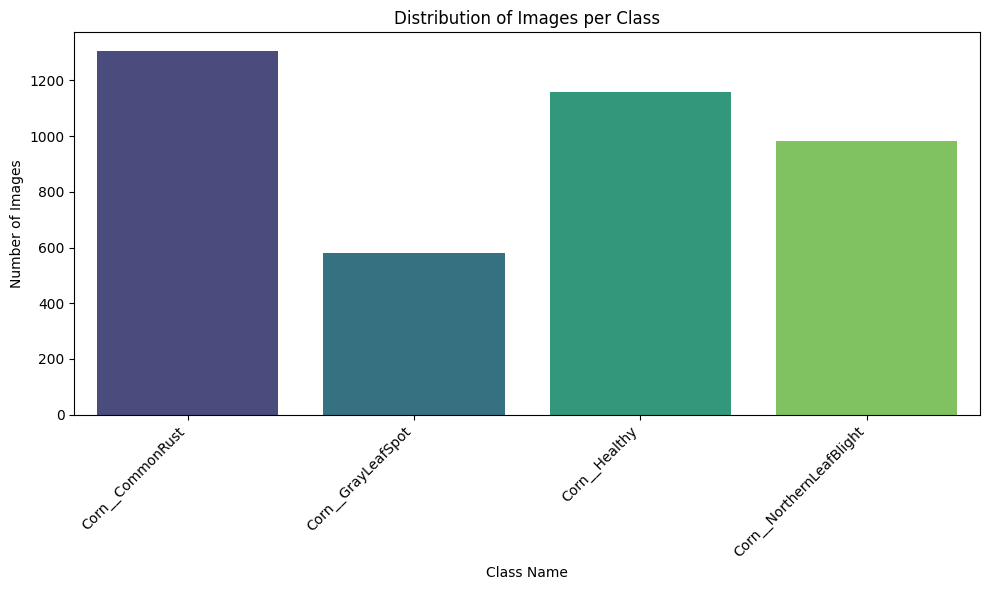

In [ ]:
# data to be plotted
class_names = list(id_to_name.values())
file_counts = []
for cls_name in class_names:
    n_files = len(os.listdir(os.path.join(combined_dir, cls_name)))
    file_counts.append(n_files)

df_dist = pd.DataFrame({
    'Class': class_names,
    'Count': file_counts
})

# displaying the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')
plt.title('Distribution of Images per Class')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Display Random Images per Class

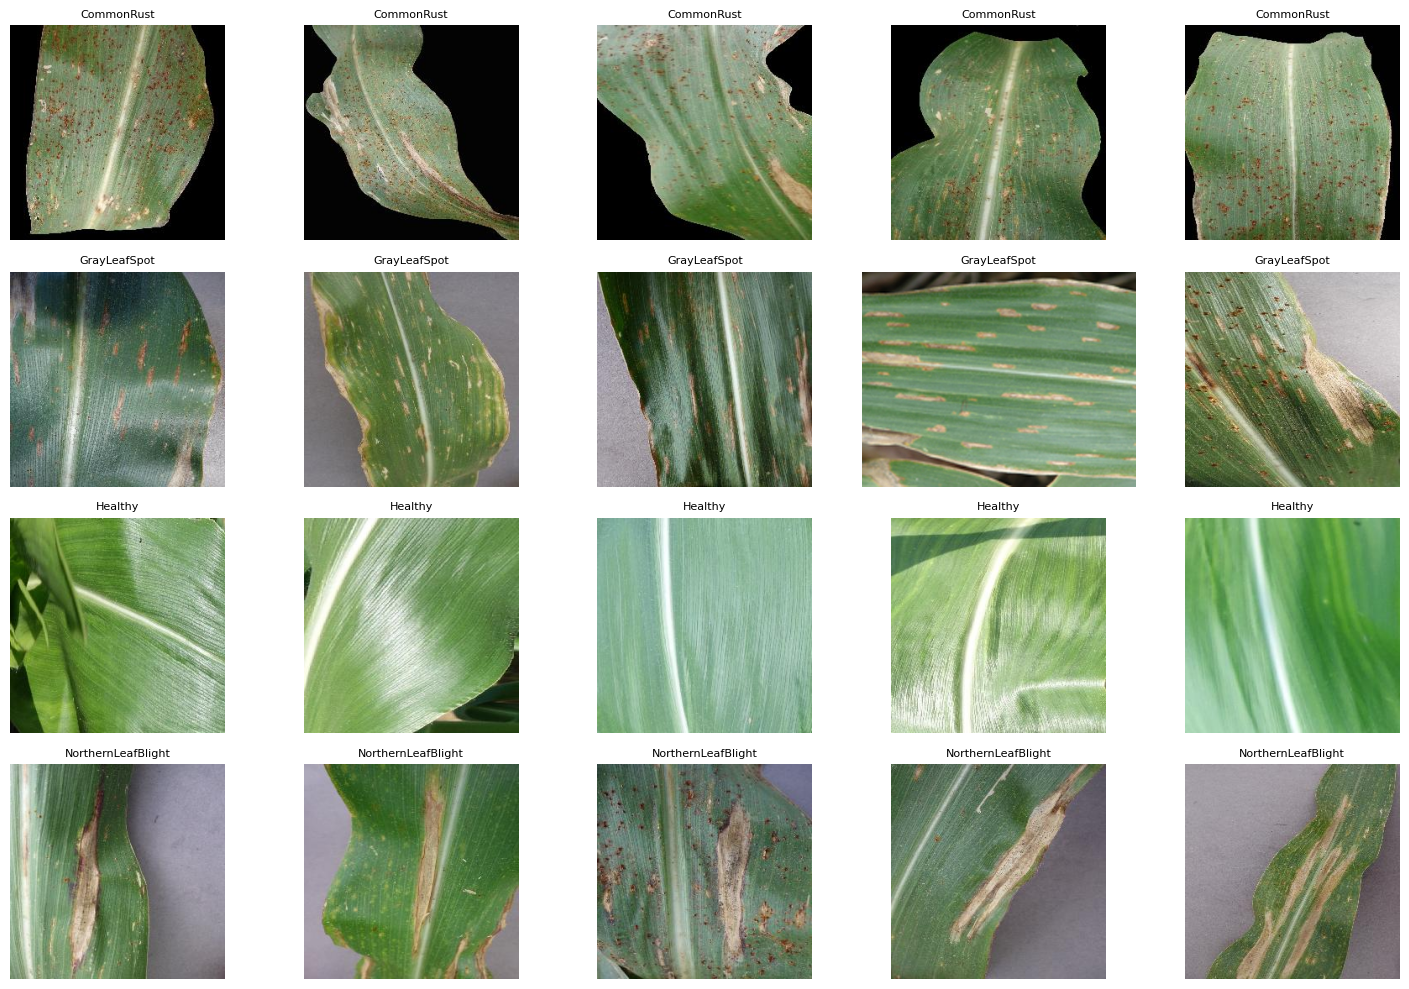

In [ ]:
plt.figure(figsize=(15, 10))

num_images_to_display = 5

for i, cls_name in enumerate(id_to_name.values()):
    class_path = os.path.join(combined_dir, cls_name)
    all_images = os.listdir(class_path)

    # take a random sample from each class
    sample_images = random.sample(all_images, min(num_images_to_display, len(all_images)))

    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        #displaying a plot image
        plt.subplot(len(id_to_name), num_images_to_display, i * num_images_to_display + j + 1)
        plt.imshow(img)
        plt.title(f"{cls_name.split('__')[-1].replace('Corn__', '')}", fontsize=8)
        plt.axis('off')

plt.tight_layout()
plt.show()

#### Split Dataset

In [ ]:
split_base = "corn-leaf-image/split"
splits = ["train", "val", "test"]
for split in splits:
    for cls_name in id_to_name.values():
        os.makedirs(os.path.join(split_base, split, cls_name), exist_ok=True)

TRAIN_RATIO, VAL_RATIO = 0.70, 0.15  # the remaining 0.15 for testing
random.seed(42)

for cls_name in id_to_name.values():
    cls_dir = os.path.join(combined_dir, cls_name)
    files = os.listdir(cls_dir)
    random.shuffle(files)

    n_total = len(files)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    for fname in train_files:
        shutil.copy(os.path.join(cls_dir, fname),
                    os.path.join(split_base, "train", cls_name, fname))
    for fname in val_files:
        shutil.copy(os.path.join(cls_dir, fname),
                    os.path.join(split_base, "val", cls_name, fname))
    for fname in test_files:
        shutil.copy(os.path.join(cls_dir, fname),
                    os.path.join(split_base, "test", cls_name, fname))

    print(f"{cls_name}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

Corn__CommonRust: train=914, val=196, test=197
Corn__GrayLeafSpot: train=406, val=87, test=87
Corn__Healthy: train=809, val=173, test=175
Corn__NorthernLeafBlight: train=688, val=147, test=148


In [ ]:
AUG_TARGET_SIZE = (224, 224)


def anticlockwise_rotation(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.rot90(img, k=random.randint(1, 4))
    return img


def clockwise_rotation(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.rot90(img, k=random.randint(1, 4))
    return img


def flip_up_down(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.flip_up_down(img)
    return img


def add_brightness(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    img = tf.image.adjust_brightness(img, delta=random.uniform(0.1, 0.5))
    img = tf.clip_by_value(img, 0, 255)
    return img


def sheared(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    datagen = ImageDataGenerator(shear_range=0.2)
    img_np = img.numpy() if hasattr(img, "numpy") else img
    img_aug = next(iter(datagen.flow(np.expand_dims(img_np, 0), batch_size=1)))[0]
    return img_aug


def warp_shift(img):
    img = tf.image.resize(img, AUG_TARGET_SIZE)
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1)
    img_np = img.numpy() if hasattr(img, "numpy") else img
    img_aug = next(iter(datagen.flow(np.expand_dims(img_np, 0), batch_size=1)))[0]
    return img_aug


AUGMENTATION_FUNCTIONS = {
    "rotCCW": anticlockwise_rotation,
    "rotCW": clockwise_rotation,
    "flipUD": flip_up_down,
    "bright": add_brightness,
    "shear": sheared,
    "warp": warp_shift,
}


def augment_train_folder(train_dir, n_aug_per_image=1):
    aug_names = list(AUGMENTATION_FUNCTIONS.keys())
    total_generated = 0

    for cls_name in os.listdir(train_dir):
        cls_dir = os.path.join(train_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue

        original_files = [f for f in os.listdir(cls_dir)
                           if f.lower().endswith((".jpg", ".jpeg", ".png"))]

        for fname in original_files:
            img_path = os.path.join(cls_dir, fname)
            try:
                pil_img = PILImage.open(img_path).convert("RGB")
            except Exception:
                continue
            img_array = np.array(pil_img, dtype=np.float32)

            for n in range(n_aug_per_image):
                aug_choice = random.choice(aug_names)
                aug_fn = AUGMENTATION_FUNCTIONS[aug_choice]
                try:
                    aug_img = aug_fn(img_array)
                    aug_img = np.array(aug_img)
                    aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)
                except Exception as e:
                    print(f"Gagal augmentasi {fname} dengan {aug_choice}: {e}")
                    continue

                base_name = os.path.splitext(fname)[0]
                new_fname = f"{base_name}_aug{n}_{aug_choice}.jpg"
                new_path = os.path.join(cls_dir, new_fname)

                PILImage.fromarray(aug_img).save(new_path, "JPEG")
                total_generated += 1

    return total_generated


print("Starting offline augmentation on the train folder...")
start_time = time.time()
n_generated = augment_train_folder(train_dir, n_aug_per_image=1)
elapsed = time.time() - start_time
print(f"A total of {n_generated} new augmented images were generated in {elapsed:.1f} seconds.")

for cls_name in id_to_name.values():
    n_files = len(os.listdir(os.path.join(train_dir, cls_name)))
    print(f"Train - '{cls_name}' class after augmentation: {n_files} images")

Starting offline augmentation on the train folder...


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

print("Class indices:", train_generator.class_indices)

Found 5634 images belonging to 4 classes.
Found 603 images belonging to 4 classes.
Found 607 images belonging to 4 classes.
Class indices: {'Corn__CommonRust': 0, 'Corn__GrayLeafSpot': 1, 'Corn__Healthy': 2, 'Corn__NorthernLeafBlight': 3}


## Modelling

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation="relu"),
    Dense(NUM_CLASSES, activation="softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,660 (13.18 MB)

 Trainable params: 3,454,660 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class StopAtAccuracy(Callback):
    """Stop automatic training when train & val accuracy are already >= target."""
    def __init__(self, target_acc=0.95):
        super().__init__()
        self.target_acc = target_acc

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get("accuracy", 0)
        val_acc = logs.get("val_accuracy", 0)
        if acc >= self.target_acc and val_acc >= self.target_acc:
            print(f"\nTrain and val accuracy have reached {self.target_acc*100:.0f}%, training stopped.")
            self.model.stop_training = True

callbacks = [
    StopAtAccuracy(target_acc=0.95),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]


In [ ]:

EPOCHS = 50

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 49s 236ms/step - accuracy: 0.7815 - loss: 0.5458 - val_accuracy: 0.8209 - val_loss: 0.3899 - learning_rate: 0.0010
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 37s 209ms/step - accuracy: 0.8360 - loss: 0.3873 - val_accuracy: 0.8176 - val_loss: 0.3841 - learning_rate: 0.0010
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.8585 - loss: 0.3424 - val_accuracy: 0.8673 - val_loss: 0.2919 - learning_rate: 0.0010
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 37s 207ms/step - accuracy: 0.8672 - loss: 0.3158 - val_accuracy: 0.9055 - val_loss: 0.2193 - learning_rate: 0.0010
Epoch 5/50
 55/177 ━━━━━━━━━━━━━━━━━━━━ 24s 200ms/step - accuracy: 0.8861 - loss: 0.2800

## Evaluation dan Visualisation

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.savefig("corn-leaf-image/loss_plot_accuration.png")
plt.show()


In [ ]:
test_generator.reset()
y_true = test_generator.classes  # label asli sesuai urutan file di generator

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_labels = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig("corn-leaf-image/confusion_matrix.png")
plt.show()

In [ ]:
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))


## Model Conversion

In [ ]:
submission_dir = "model"
os.makedirs(submission_dir, exist_ok=True)

# 11a. SavedModel -> model/saved_model/
saved_model_dir = os.path.join(submission_dir, "saved_model")
model.export(saved_model_dir)
print("SavedModel disimpan di:", saved_model_dir)

# 11b. TF-Lite -> model/tflite/
tflite_dir = os.path.join(submission_dir, "tflite")
os.makedirs(tflite_dir, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

tflite_path = os.path.join(tflite_dir, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print("TF-Lite model disimpan di:", tflite_path)

# Label TF-Lite -> submission/tflite/label.txt
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
label_path = os.path.join(tflite_dir, "label.txt")
with open(label_path, "w") as f:
    for i in range(len(idx_to_class)):
        f.write(idx_to_class[i] + "\n")
print("Label disimpan di:", label_path)


tfjs_dir = os.path.join(submission_dir, "tfjs_model")
os.makedirs(tfjs_dir, exist_ok=True)
tfjs.converters.save_keras_model(model, tfjs_dir)
print("TFJS model disimpan di:", tfjs_dir)

## Inference (Optional)

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_generator.reset()
sample_images, sample_labels = next(test_generator)

print("\n=== HASIL INFERENCE (TF-Lite) ===")
n_show = min(6, len(sample_images))
plt.figure(figsize=(15, 6))
for i in range(n_show):
    img = sample_images[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], img)
    interpreter.invoke()
    pred_probs = interpreter.get_tensor(output_details[0]["index"])[0]

    pred_idx = int(np.argmax(pred_probs))
    confidence = pred_probs[pred_idx]
    pred_class = idx_to_class[pred_idx]

    true_idx = int(np.argmax(sample_labels[i]))
    true_class = idx_to_class[true_idx]

    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"Pred: {pred_class} ({confidence*100:.1f}%)\nActual: {true_class}")
    plt.axis("off")

    print(f"Sample {i+1}: Predicted={pred_class} ({confidence*100:.1f}%), Actual={true_class}")

plt.tight_layout()
plt.savefig(os.path.join(submission_dir, "inference_result.png"))
plt.show()


Deploy Gradio

In [ ]:

import numpy as np
from PIL import Image
import gradio as gr

TFLITE_PATH = "model/tflite/model.tflite"
LABEL_PATH = "model/tflite/label.txt"
IMG_SIZE = (150, 150)  # harus sama dengan saat training

with open(LABEL_PATH, "r") as f:
    class_labels = [line.strip() for line in f if line.strip()]

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


def preprocess(image: Image.Image) -> np.ndarray:
    image = image.convert("RGB").resize(IMG_SIZE)
    arr = np.array(image, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return arr


def predict(image: Image.Image):
    if image is None:
        return {}
    input_data = preprocess(image)
    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]["index"])[0]
    return {class_labels[i]: float(probs[i]) for i in range(len(class_labels))}


demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload gambar daun jagung"),
    outputs=gr.Label(num_top_classes=len(class_labels), label="Hasil Klasifikasi"),
    title="Klasifikasi Penyakit Daun Jagung",
    description="Upload foto daun jagung, model akan memprediksi jenis penyakitnya.",
)

# share=True wajib di Colab supaya dapat public link (localhost gak bisa diakses)
demo.launch(share=True, debug=True)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

# ---- MobileNetV2 butuh preprocessing khusus (bukan rescale 1/255) ----
# jadi generator dibuat ulang, target size & struktur folder tetap sama
mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)
mobilenet_val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

mobilenet_train_generator = mobilenet_train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical",
)
mobilenet_val_generator = mobilenet_val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical",
)
mobilenet_test_generator = mobilenet_val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False,
)


In [ ]:
base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze backbone -> feature extraction, bukan full fine-tune dulu

In [ ]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax"),
])

mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

mobilenet_model.summary()

In [ ]:
early_stop = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

mobilenet_history = mobilenet_model.fit(
    mobilenet_train_generator,
    validation_data=mobilenet_val_generator,
    epochs=20,
    callbacks=[early_stop],
)

In [ ]:
base_model.trainable = True

# Bekukan layer awal (fitur generik: tepi, tekstur), hanya buka layer akhir
# (fitur lebih spesifik ke domain) supaya nggak merusak bobot pretrained.
FINE_TUNE_AT = 100  # dari total ~155 layer di MobileNetV2
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR jauh lebih kecil dari training awal
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

mobilenet_finetune_history = mobilenet_model.fit(
    mobilenet_train_generator,
    validation_data=mobilenet_val_generator,
    epochs=10,
    callbacks=[early_stop],
)

In [ ]:
mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(mobilenet_test_generator)
print(f"[MobileNetV2] Test accuracy: {mobilenet_test_acc*100:.2f}%")
print(f"[MobileNetV2] Test loss: {mobilenet_test_loss:.4f}")

mobilenet_test_generator.reset()
y_true_mn = mobilenet_test_generator.classes
y_pred_probs_mn = mobilenet_model.predict(mobilenet_test_generator, verbose=1)
y_pred_mn = np.argmax(y_pred_probs_mn, axis=1)

print("\n=== Classification Report (MobileNetV2) ===")
print(classification_report(y_true_mn, y_pred_mn, target_names=class_labels))

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["CNN Scratch", "MobileNetV2 (Transfer Learning)"],
    "Test Accuracy": [test_acc, mobilenet_test_acc],
    "Test Loss": [test_loss, mobilenet_test_loss],
    "Jumlah Parameter": [model.count_params(), mobilenet_model.count_params()],
})
print(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Test Accuracy", data=comparison_df, palette="viridis")
plt.title("Perbandingan Test Accuracy: CNN Scratch vs MobileNetV2")
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.tight_layout()
plt.show()

In [ ]:

submission_dir = "model_mobilenet"
os.makedirs(submission_dir, exist_ok=True)

# ---- Label mapping: pakai class_indices dari generator MobileNetV2 ----
mobilenet_class_indices = mobilenet_train_generator.class_indices
mobilenet_idx_to_class = {v: k for k, v in mobilenet_class_indices.items()}

# 1) SavedModel -> model/saved_model/
saved_model_dir = os.path.join(submission_dir, "saved_model")
mobilenet_model.export(saved_model_dir)
print("SavedModel disimpan di:", saved_model_dir)

# 2) TF-Lite -> model/tflite/
tflite_dir = os.path.join(submission_dir, "tflite")
os.makedirs(tflite_dir, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_model = converter.convert()

tflite_path = os.path.join(tflite_dir, "model.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print("TF-Lite model disimpan di:", tflite_path)

# Label TF-Lite -> model/tflite/label.txt
label_path = os.path.join(tflite_dir, "label.txt")
with open(label_path, "w") as f:
    for i in range(len(mobilenet_idx_to_class)):
        f.write(mobilenet_idx_to_class[i] + "\n")
print("Label disimpan di:", label_path)

# 3) TFJS -> model/tfjs_model/
tfjs_dir = os.path.join(submission_dir, "tfjs_model")
os.makedirs(tfjs_dir, exist_ok=True)
tfjs.converters.save_keras_model(mobilenet_model, tfjs_dir)
print("TFJS model disimpan di:", tfjs_dir)

print("\n=== Model final yang di-deploy: MobileNetV2 (transfer learning + fine-tuned) ===")
print(f"Test accuracy: {mobilenet_test_acc*100:.2f}% | Test loss: {mobilenet_test_loss:.4f} | Params: {mobilenet_model.count_params():,}")

In [ ]:
# ============================================================
# Inference (Optional) — VERSI FINAL, pakai TFLite MobileNetV2
# Ganti cell "Inference (Optional)" yang lama dengan ini.
# PENTING: preprocessing di sini WAJIB pakai preprocess_input
# (bukan rescale 1/255), karena model dilatih dengan preprocess_input.
# ============================================================

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mn_preprocess_input

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

mobilenet_test_generator.reset()
sample_images_raw, sample_labels = next(mobilenet_test_generator)
# sample_images_raw sudah melalui preprocess_input dari generator, siap dipakai langsung

print("\n=== HASIL INFERENCE (TF-Lite, MobileNetV2) ===")
n_show = min(6, len(sample_images_raw))
plt.figure(figsize=(15, 6))
for i in range(n_show):
    img = sample_images_raw[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], img)
    interpreter.invoke()
    pred_probs = interpreter.get_tensor(output_details[0]["index"])[0]

    pred_idx = int(np.argmax(pred_probs))
    confidence = pred_probs[pred_idx]
    pred_class = mobilenet_idx_to_class[pred_idx]

    true_idx = int(np.argmax(sample_labels[i]))
    true_class = mobilenet_idx_to_class[true_idx]

    # untuk ditampilkan, un-normalize balik ke rentang [0,1] biar kelihatan wajar
    img_display = (sample_images_raw[i] + 1.0) / 2.0  # preprocess_input MobileNetV2 -> range [-1, 1]
    img_display = np.clip(img_display, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_display)
    plt.title(f"Pred: {pred_class} ({confidence*100:.1f}%)\nActual: {true_class}")
    plt.axis("off")

    print(f"Sample {i+1}: Predicted={pred_class} ({confidence*100:.1f}%), Actual={true_class}")

plt.tight_layout()
plt.savefig(os.path.join(submission_dir, "inference_result.png"))
plt.show()

In [ ]:
TFLITE_PATH = "model_mobilenet/tflite/model.tflite"
LABEL_PATH = "model_mobilenet/tflite/label.txt"
IMG_SIZE = (150, 150)  # harus sama dengan saat training

with open(LABEL_PATH, "r") as f:
    class_labels = [line.strip() for line in f if line.strip()]

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


def preprocess(image: Image.Image) -> np.ndarray:
    image = image.convert("RGB").resize(IMG_SIZE)
    arr = np.array(image, dtype=np.float32)
    arr = mn_preprocess_input(arr)  # normalisasi khusus MobileNetV2 -> rentang [-1, 1]
    arr = np.expand_dims(arr, axis=0)
    return arr


def predict(image: Image.Image):
    if image is None:
        return {}
    input_data = preprocess(image)
    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]["index"])[0]
    return {class_labels[i]: float(probs[i]) for i in range(len(class_labels))}


demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload gambar daun jagung"),
    outputs=gr.Label(num_top_classes=len(class_labels), label="Hasil Klasifikasi"),
    title="Klasifikasi Penyakit Daun Jagung (MobileNetV2)",
    description="Upload foto daun jagung, model akan memprediksi jenis penyakitnya. Model: MobileNetV2 (transfer learning + fine-tuned).",
)

# share=True wajib di Colab supaya dapat public link (localhost gak bisa diakses)
demo.launch(share=True, debug=True)

In [ ]:
# ============================================================
# Optimasi Inference: Quantization + Benchmark
# Taruh cell ini SETELAH cell "Konversi Model" (konversi_model_final.py)
# dan SEBELUM/SETELAH "Inference (Optional)" — butuh variabel:
# saved_model_dir, tflite_path, mobilenet_test_generator,
# mobilenet_model, mobilenet_idx_to_class
# ============================================================

import time

# ============================================================
# 1) Buat versi TFLite yang di-quantize (dynamic range quantization)
#    Ini yang bikin ukuran file lebih kecil & inference lebih cepat
#    di CPU, tanpa perlu representative dataset seperti full-int8.
# ============================================================
converter_quant = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]  # aktifkan dynamic range quantization
tflite_quant_model = converter_quant.convert()

tflite_quant_path = os.path.join(tflite_dir, "model_quant.tflite")
with open(tflite_quant_path, "wb") as f:
    f.write(tflite_quant_model)
print("TF-Lite quantized model disimpan di:", tflite_quant_path)


# ============================================================
# 2) Bandingkan ukuran file: SavedModel vs TFLite vs TFLite-quantized
# ============================================================
def get_dir_size(path):
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total

size_saved_model = get_dir_size(saved_model_dir)
size_tflite = os.path.getsize(tflite_path)
size_tflite_quant = os.path.getsize(tflite_quant_path)

size_df = pd.DataFrame({
    "Format": ["SavedModel", "TFLite (float32)", "TFLite (quantized)"],
    "Ukuran (MB)": [size_saved_model / 1e6, size_tflite / 1e6, size_tflite_quant / 1e6],
})
print("\n=== Perbandingan Ukuran Model ===")
print(size_df)


# ============================================================
# 3) Benchmark latency inference per gambar (rata-rata dari N sample)
# ============================================================
N_BENCHMARK = 50  # jumlah gambar yang dipakai untuk diukur

mobilenet_test_generator.reset()
benchmark_images = []
collected = 0
while collected < N_BENCHMARK:
    batch_x, _ = next(mobilenet_test_generator)
    for img in batch_x:
        benchmark_images.append(img)
        collected += 1
        if collected >= N_BENCHMARK:
            break
benchmark_images = np.array(benchmark_images, dtype=np.float32)


def benchmark_keras(model, images, n_warmup=5):
    # warmup supaya nggak ikut ngukur overhead compile graph pertama kali
    for i in range(n_warmup):
        model.predict(images[i:i+1], verbose=0)
    start = time.time()
    for i in range(len(images)):
        model.predict(images[i:i+1], verbose=0)
    elapsed = time.time() - start
    return elapsed / len(images) * 1000  # ms per gambar


def benchmark_tflite(model_path, images, n_warmup=5):
    interp = tf.lite.Interpreter(model_path=model_path)
    interp.allocate_tensors()
    in_details = interp.get_input_details()
    out_details = interp.get_output_details()

    for i in range(n_warmup):
        interp.set_tensor(in_details[0]["index"], images[i:i+1])
        interp.invoke()

    start = time.time()
    for i in range(len(images)):
        interp.set_tensor(in_details[0]["index"], images[i:i+1])
        interp.invoke()
        _ = interp.get_tensor(out_details[0]["index"])
    elapsed = time.time() - start
    return elapsed / len(images) * 1000  # ms per gambar


print(f"\nMenjalankan benchmark dengan {N_BENCHMARK} gambar...")
latency_keras = benchmark_keras(mobilenet_model, benchmark_images)
latency_tflite = benchmark_tflite(tflite_path, benchmark_images)
latency_tflite_quant = benchmark_tflite(tflite_quant_path, benchmark_images)

latency_df = pd.DataFrame({
    "Format": ["Keras (SavedModel)", "TFLite (float32)", "TFLite (quantized)"],
    "Latency per gambar (ms)": [latency_keras, latency_tflite, latency_tflite_quant],
})
print("\n=== Perbandingan Latency Inference ===")
print(latency_df)


# ============================================================
# 4) Cek akurasi TFLite-quantized tidak turun signifikan
#    (quantization kadang mengorbankan sedikit akurasi demi ukuran/speed)
# ============================================================
interp_quant = tf.lite.Interpreter(model_path=tflite_quant_path)
interp_quant.allocate_tensors()
in_details_q = interp_quant.get_input_details()
out_details_q = interp_quant.get_output_details()

mobilenet_test_generator.reset()
y_true_q, y_pred_q = [], []
for _ in range(len(mobilenet_test_generator)):
    batch_x, batch_y = next(mobilenet_test_generator)
    for img, label in zip(batch_x, batch_y):
        interp_quant.set_tensor(in_details_q[0]["index"], img[np.newaxis, ...].astype(np.float32))
        interp_quant.invoke()
        probs = interp_quant.get_tensor(out_details_q[0]["index"])[0]
        y_pred_q.append(int(np.argmax(probs)))
        y_true_q.append(int(np.argmax(label)))

quant_acc = np.mean(np.array(y_true_q) == np.array(y_pred_q))
print(f"\n[TFLite Quantized] Test accuracy: {quant_acc*100:.2f}% (dibanding MobileNetV2 asli: {mobilenet_test_acc*100:.2f}%)")


# ============================================================
# 5) Ringkasan gabungan: ukuran + latency + akurasi
# ============================================================
summary_df = pd.DataFrame({
    "Format": ["Keras/SavedModel", "TFLite (float32)", "TFLite (quantized)"],
    "Ukuran (MB)": [size_saved_model / 1e6, size_tflite / 1e6, size_tflite_quant / 1e6],
    "Latency (ms/gambar)": [latency_keras, latency_tflite, latency_tflite_quant],
    "Test Accuracy": [mobilenet_test_acc, mobilenet_test_acc, quant_acc],
})
print("\n=== Ringkasan Optimasi Inference ===")
print(summary_df)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x="Format", y="Ukuran (MB)", data=summary_df, hue="Format", legend=False, palette="viridis")
plt.title("Ukuran Model per Format")
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.barplot(x="Format", y="Latency (ms/gambar)", data=summary_df, hue="Format", legend=False, palette="magma")
plt.title("Latency Inference per Format")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()